# Mamba-2 — CATSA Train → EmpaticaE4 Test (ACC only)

**Model**: Mamba-2 (Structured State Space Dual — SSD, pure PyTorch)
- Selective SSM with input-dependent state transitions (B, C, Δ)
- CNN front-end reduces L 1920→120 (÷16) for efficient sequential scan
- 참고: *Transformers are SSMs: Generalized Models and Efficient Algorithms* (Dao & Gu, 2024)

**학습**: CATSA 전체 피험자 (ACC 3축, 32Hz)  
**평가**: EmpaticaE4Stress (subject_01 ~ subject_06)

In [1]:
import json, math
import numpy as np
import pandas as pd
from copy import deepcopy
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

TASKS        = ["Baseline", "Logic", "Nback", "Stroop", "Sudoku"]
STRESS_TASKS = {"Logic", "Nback", "Stroop", "Sudoku"}
ACC_FS       = 32

CATSA_ROOT  = Path("/home/binghin2/Myproject/Dataset/CATSA")
E4_ROOT     = Path("/home/binghin2/Myproject/Dataset/EmpaticaE4Stress/Subjects")
SUBJECTS_E4 = [f"subject_{i:02d}" for i in range(1, 7)]
SAVE_DIR    = Path("/home/binghin2/Myproject/Research/CATSA/Train/Individual_data/ACC/Save_model_Mamba2")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

def discover_subjects(root):
    out = []
    for d in sorted(root.glob("Sub*"), key=lambda p: int(p.name[3:])):
        if d.is_dir() and all((d / t / "ACC.csv").exists() for t in TASKS):
            out.append(d.name)
    return out

def read_acc(path):
    df   = pd.read_csv(path)
    cols = ["ACC_X", "ACC_Y", "ACC_Z"]
    vals = df[cols].to_numpy(np.float32) if all(c in df.columns for c in cols) \
           else df[[c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])][:3]].to_numpy(np.float32)
    return vals[~np.any(np.isnan(vals), axis=1)]

def make_windows(sig, W, S):
    if len(sig) < W: return np.empty((0, sig.shape[1], W), np.float32)
    return np.asarray([sig[i:i+W].T for i in range(0, len(sig)-W+1, S)], np.float32)

def build_catsa_arrays(subjects, W, S):
    xs, ys = [], []
    for sub in subjects:
        path  = CATSA_ROOT / sub
        all_v = np.concatenate([read_acc(path / t / "ACC.csv") for t in TASKS])
        mu    = np.mean(all_v, axis=0, keepdims=True).astype(np.float32)
        sigma = (np.std(all_v, axis=0, keepdims=True) + 1e-8).astype(np.float32)
        for task in TASKS:
            norm = (read_acc(path / task / "ACC.csv") - mu) / sigma
            w    = make_windows(norm, W, S)
            if len(w): xs.append(w); ys.append(np.full(len(w), int(task in STRESS_TASKS), np.int64))
    return np.concatenate(xs), np.concatenate(ys)

def build_e4_labels(n, fs=32):
    fixed_s = {"rest0":180,"task1":600,"rest1":120,"task2":300,"rest2":120,
               "task3":180,"rest3":120,"rest4":120,"task5":60,"rest5":120}
    task4_s = n // fs - sum(fixed_s.values())
    if task4_s <= 0: raise ValueError(f"Signal too short: {n/fs:.0f}s")
    segs = [("rest0",180,0),("task1",600,1),("rest1",120,-1),("task2",300,1),
            ("rest2",120,-1),("task3",180,1),("rest3",120,-1),("task4",task4_s,1),
            ("rest4",120,-1),("task5",60,1),("rest5",120,-1)]
    labels = np.full(n, -1, np.int64)
    cur = 0
    for _, dur_s, lab in segs:
        end = min(cur + dur_s * fs, n)
        if end > cur: labels[cur:end] = lab
        cur = end
        if cur >= n: break
    return labels, int(task4_s)

def e4_windows(acc, labels, W, S):
    mask  = labels >= 0
    mu    = np.mean(acc[mask], axis=0) if mask.any() else np.mean(acc, axis=0)
    sigma = (np.std(acc[mask], axis=0) + 1e-8) if mask.any() else (np.std(acc, axis=0) + 1e-8)
    norm  = ((acc - mu) / sigma).astype(np.float32)
    xs, ys = [], []
    for i in range(0, len(norm) - W + 1, S):
        u = np.unique(labels[i:i+W])
        if len(u) == 1 and u[0] in (0,1): xs.append(norm[i:i+W].T); ys.append(int(u[0]))
    if not xs: return np.empty((0,3,W), np.float32), np.empty(0, np.int64)
    return np.asarray(xs, np.float32), np.asarray(ys, np.int64)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__(); self.gamma, self.alpha = gamma, alpha
    def forward(self, logits, y):
        y = y.float()
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        pt  = torch.sigmoid(logits)*y + (1-torch.sigmoid(logits))*(1-y)
        fl  = (1-pt).pow(self.gamma)*bce
        if self.alpha is not None: fl = (self.alpha*y+(1-self.alpha)*(1-y))*fl
        return fl.mean()

def make_loader(x, y, bs, shuffle):
    return DataLoader(TensorDataset(torch.from_numpy(x), torch.from_numpy(y).float()),
                      batch_size=bs, shuffle=shuffle)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval(); tot=n=tp=tn=fp=fn=0
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE); lg=model(xb)
        tot+=criterion(lg,yb).item()*len(xb); n+=len(xb)
        pred=(torch.sigmoid(lg)>=0.5).long(); yi=yb.long()
        tp+=int(((pred==1)&(yi==1)).sum()); tn+=int(((pred==0)&(yi==0)).sum())
        fp+=int(((pred==1)&(yi==0)).sum()); fn+=int(((pred==0)&(yi==1)).sum())
    acc=(tp+tn)/max(n,1); pre=tp/max(tp+fp,1); rec=tp/max(tp+fn,1)
    return {"loss":tot/max(n,1),"accuracy":acc,"f1":2*pre*rec/max(pre+rec,1e-8),
            "precision":pre,"recall":rec,"tp":tp,"tn":tn,"fp":fp,"fn":fn}

def train_epoch(model, loader, optimizer, criterion):
    model.train(); tot=n=0
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss=criterion(model(xb),yb); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
        tot+=loss.item()*len(xb); n+=len(xb)
    return tot/max(n,1)

print("Utilities loaded.")

Device: cuda
Utilities loaded.


In [2]:
# ── Mamba-2 Model (Pure PyTorch) ──────────────────────────────────────────
class Mamba2Block(nn.Module):
    """
    Mamba-2 core block.
    Implements a selective SSM (SSD) with input-dependent B, C, and Δ parameters.
    Uses a sequential scan over the time axis (efficient for L~120 after CNN frontend).
    """
    def __init__(self, d_model: int = 128, d_state: int = 16,
                 d_conv: int = 4, expand: int = 2):
        super().__init__()
        d_inner      = d_model * expand
        self.d_inner = d_inner
        self.d_state = d_state

        self.norm    = nn.LayerNorm(d_model)
        self.in_proj = nn.Linear(d_model, d_inner * 2, bias=False)
        self.conv1d  = nn.Conv1d(d_inner, d_inner, d_conv,
                                 padding=d_conv - 1, groups=d_inner)
        # projects to: [dt (1), B (d_state), C (d_state)]
        self.x_proj  = nn.Linear(d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, d_inner, bias=True)

        A            = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(d_inner, 1)
        self.A_log   = nn.Parameter(torch.log(A))   # [d_inner, d_state]
        self.D       = nn.Parameter(torch.ones(d_inner))
        self.out_proj= nn.Linear(d_inner, d_model, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, L, d_model]
        residual = x
        x        = self.norm(x)
        B, L, _  = x.shape

        xz      = self.in_proj(x)                           # [B, L, 2*d_inner]
        x_in, z = xz.chunk(2, dim=-1)                       # [B, L, d_inner]

        # Depthwise causal conv
        x_conv  = self.conv1d(x_in.transpose(1, 2))[:, :, :L].transpose(1, 2)
        x_conv  = F.silu(x_conv)

        # Input-dependent SSM parameters
        x_dbl              = self.x_proj(x_conv)             # [B, L, 2N+1]
        dt_raw, B_s, C_s   = x_dbl.split([1, self.d_state, self.d_state], dim=-1)
        dt                 = F.softplus(self.dt_proj(dt_raw))# [B, L, d_inner]
        A                  = -torch.exp(self.A_log.float())  # [d_inner, d_state]

        y = self._selective_scan(x_conv, dt, A, B_s, C_s)
        y = y * F.silu(z)
        return self.out_proj(y) + residual

    def _selective_scan(self, u, dt, A, B, C):
        # u, dt : [BS, L, D]
        # A     : [D, N]
        # B, C  : [BS, L, N]
        BS, L, D = u.shape
        N        = self.d_state

        # Discretise A and B
        dA = torch.exp(dt.unsqueeze(-1) * A)          # [BS, L, D, N]
        dB = dt.unsqueeze(-1) * B.unsqueeze(2)         # [BS, L, D, N]

        h   = u.new_zeros(BS, D, N)
        ys  = []
        for i in range(L):
            h = dA[:, i] * h + dB[:, i] * u[:, i].unsqueeze(-1)  # [BS, D, N]
            ys.append((h * C[:, i].unsqueeze(1)).sum(-1))          # [BS, D]

        y = torch.stack(ys, dim=1)                      # [BS, L, D]
        y = y + u * self.D                               # skip connection via D
        return y


class Mamba2Classifier(nn.Module):
    """
    Full Mamba-2 stress classifier.
    CNN frontend: [B,3,1920] → [B, d_model, 120]  (4× MaxPool2)
    Mamba-2 blocks: temporal sequence modelling on L=120
    Mean pool + classification head.
    """
    def __init__(self, n_channels: int = 3, d_model: int = 128,
                 d_state: int = 16, n_layers: int = 3, dropout: float = 0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_channels, 32, 5, padding=2), nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32,  64,  5, padding=2), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64,  d_model, 3, padding=1),                   nn.ReLU(), nn.MaxPool1d(2),
            nn.MaxPool1d(2),
        )  # 1920 / 16 = 120

        self.input_norm   = nn.LayerNorm(d_model)
        self.mamba_blocks = nn.ModuleList([
            Mamba2Block(d_model=d_model, d_state=d_state) for _ in range(n_layers)
        ])
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, 3, 1920]
        h = self.cnn(x).transpose(1, 2)   # [B, 120, d_model]
        h = self.input_norm(h)
        for blk in self.mamba_blocks:
            h = blk(h)
        h = h.mean(dim=1)                  # [B, d_model]
        return self.head(h).squeeze(-1)    # [B]


# Architecture check
model_test = Mamba2Classifier()
x_dummy    = torch.randn(4, 3, 1920)
out_test   = model_test(x_dummy)
print(f"Input: {x_dummy.shape}  Output: {out_test.shape}")
n_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
del model_test, x_dummy, out_test

Input: torch.Size([4, 3, 1920])  Output: torch.Size([4])
Trainable parameters: 384,001


In [3]:
# ── Hyperparameters & Training on CATSA ──────────────────────────────────
HP = {
    "seed"        : 42,
    "val_ratio"   : 0.10,
    "window_size" : ACC_FS * 60,
    "stride"      : ACC_FS * 10,
    "batch_size"  : 8,
    "epochs"      : 50,
    "lr"          : 1e-3,
    "wd"          : 1e-4,
    "patience"    : 8,
    # Mamba-2
    "d_model"     : 128,
    "d_state"     : 16,
    "n_layers"    : 3,
    "dropout"     : 0.3,
}

np.random.seed(HP["seed"]); torch.manual_seed(HP["seed"])
if torch.cuda.is_available(): torch.cuda.manual_seed_all(HP["seed"])

subjects  = discover_subjects(CATSA_ROOT)
print(f"Total CATSA subjects: {len(subjects)}")

rng       = np.random.default_rng(HP["seed"])
idx       = rng.permutation(len(subjects))
n_val     = max(4, int(len(subjects) * HP["val_ratio"]))
val_subs  = [subjects[i] for i in sorted(idx[:n_val])]
train_subs= [subjects[i] for i in sorted(idx[n_val:])]
print(f"Train: {len(train_subs)} | Val: {len(val_subs)}")

W, S = HP["window_size"], HP["stride"]
print("Building training arrays...")
x_train, y_train = build_catsa_arrays(train_subs, W, S)
x_val,   y_val   = build_catsa_arrays(val_subs,   W, S)
print(f"Train: {x_train.shape}  Val: {x_val.shape}")

loader_tr = make_loader(x_train, y_train, HP["batch_size"], True)
loader_va = make_loader(x_val,   y_val,   HP["batch_size"], False)

pos       = float(y_train.sum())
alpha     = float((len(y_train) - pos) / len(y_train))
criterion = FocalLoss(gamma=2.0, alpha=alpha).to(DEVICE)

model = Mamba2Classifier(
    d_model  = HP["d_model"],
    d_state  = HP["d_state"],
    n_layers = HP["n_layers"],
    dropout  = HP["dropout"],
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=HP["lr"], weight_decay=HP["wd"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=4)

best_val_loss = float("inf"); best_state = None; wait = 0; history = []

for epoch in range(1, HP["epochs"] + 1):
    tr_loss = train_epoch(model, loader_tr, optimizer, criterion)
    val_m   = evaluate(model, loader_va, criterion)
    scheduler.step(val_m["loss"])
    history.append({"epoch":epoch,"train_loss":tr_loss,"val_loss":val_m["loss"],"val_f1":val_m["f1"]})
    if val_m["loss"] < best_val_loss:
        best_val_loss = val_m["loss"]; best_epoch = epoch; wait = 0
        best_state = deepcopy(model.state_dict())
        torch.save({"model_state_dict":best_state,"hp":HP,"epoch":epoch},
                   SAVE_DIR / "best_model.pt")
    else:
        wait += 1
        if wait >= HP["patience"]:
            print(f"Early stopping at epoch {epoch} (best: {best_epoch})"); break
    if epoch % 5 == 0 or epoch == 1:
        print(f"[{epoch:3d}] train={tr_loss:.4f}  val={val_m['loss']:.4f}  "
              f"f1={val_m['f1']:.4f}  lr={optimizer.param_groups[0]['lr']:.2e}")

model.load_state_dict(best_state)
print(f"\nTraining complete. Best epoch: {best_epoch}, best_val_loss: {best_val_loss:.4f}")

Total CATSA subjects: 50
Train: 45 | Val: 5
Building training arrays...
Train: (2925, 3, 1920)  Val: (325, 3, 1920)
[  1] train=0.0534  val=0.0526  f1=0.5376  lr=1.00e-03
[  5] train=0.0493  val=0.0504  f1=0.7593  lr=1.00e-03
[ 10] train=0.0490  val=0.0537  f1=0.6177  lr=5.00e-04
Early stopping at epoch 13 (best: 5)

Training complete. Best epoch: 5, best_val_loss: 0.0504


In [4]:
# ── Evaluate on EmpaticaE4Stress ──────────────────────────────────────────
model.eval()
all_true, all_pred = [], []
rows = []

for sub in SUBJECTS_E4:
    acc = read_acc(E4_ROOT / sub / "ACC.csv")
    labels, task4_sec = build_e4_labels(len(acc))
    x, y_true = e4_windows(acc, labels, W, S)
    if len(x) == 0:
        rows.append({"subject":sub,"n_windows":0,"accuracy":float("nan"),
                     "f1":float("nan"),"precision":float("nan"),"recall":float("nan")})
        continue
    with torch.no_grad():
        logits = model(torch.from_numpy(x).to(DEVICE))
        y_pred = (torch.sigmoid(logits) >= 0.5).cpu().numpy().astype(int)
    rows.append({
        "subject":sub, "task4_sec":task4_sec, "n_windows":len(y_true),
        "accuracy":float(accuracy_score(y_true,y_pred)),
        "f1":float(f1_score(y_true,y_pred,zero_division=0)),
        "precision":float(precision_score(y_true,y_pred,zero_division=0)),
        "recall":float(recall_score(y_true,y_pred,zero_division=0)),
    })
    all_true.extend(y_true.tolist()); all_pred.extend(y_pred.tolist())

result_df = pd.DataFrame(rows)
print("=== Per-subject metrics ===")
display(result_df)

if all_true:
    ov_acc  = accuracy_score(all_true, all_pred)
    ov_f1   = f1_score(all_true, all_pred, zero_division=0)
    ov_prec = precision_score(all_true, all_pred, zero_division=0)
    ov_rec  = recall_score(all_true, all_pred, zero_division=0)
    print(f"\n=== Overall ===")
    print(f"Accuracy : {ov_acc:.4f}")
    print(f"F1       : {ov_f1:.4f}")
    print(f"Precision: {ov_prec:.4f}")
    print(f"Recall   : {ov_rec:.4f}")
    cm = confusion_matrix(all_true, all_pred)
    print("\nConfusion Matrix:"); print(cm)
    print("\n", classification_report(all_true, all_pred,
                                     target_names=["Non-stress","Stress"], zero_division=0))

=== Per-subject metrics ===


,subject,task4_sec,n_windows,accuracy,f1,precision,recall
0,subject_01,585,159,0.949686,0.972028,0.992857,0.952055
1,subject_02,435,144,0.923611,0.959707,0.922535,1.000000
2,subject_03,156,116,0.862069,0.925926,0.884956,0.970874
3,subject_04,188,119,0.991597,0.995261,1.000000,0.990566
4,subject_05,163,117,0.888889,0.941176,0.888889,1.000000
5,subject_06,243,125,0.816000,0.898678,0.886957,0.910714



=== Overall ===
Accuracy : 0.9077
F1       : 0.9498
Precision: 0.9303
Recall   : 0.9701

Confusion Matrix:
[[ 27  51]
 [ 21 681]]

               precision    recall  f1-score   support

  Non-stress       0.56      0.35      0.43        78
      Stress       0.93      0.97      0.95       702

    accuracy                           0.91       780
   macro avg       0.75      0.66      0.69       780
weighted avg       0.89      0.91      0.90       780



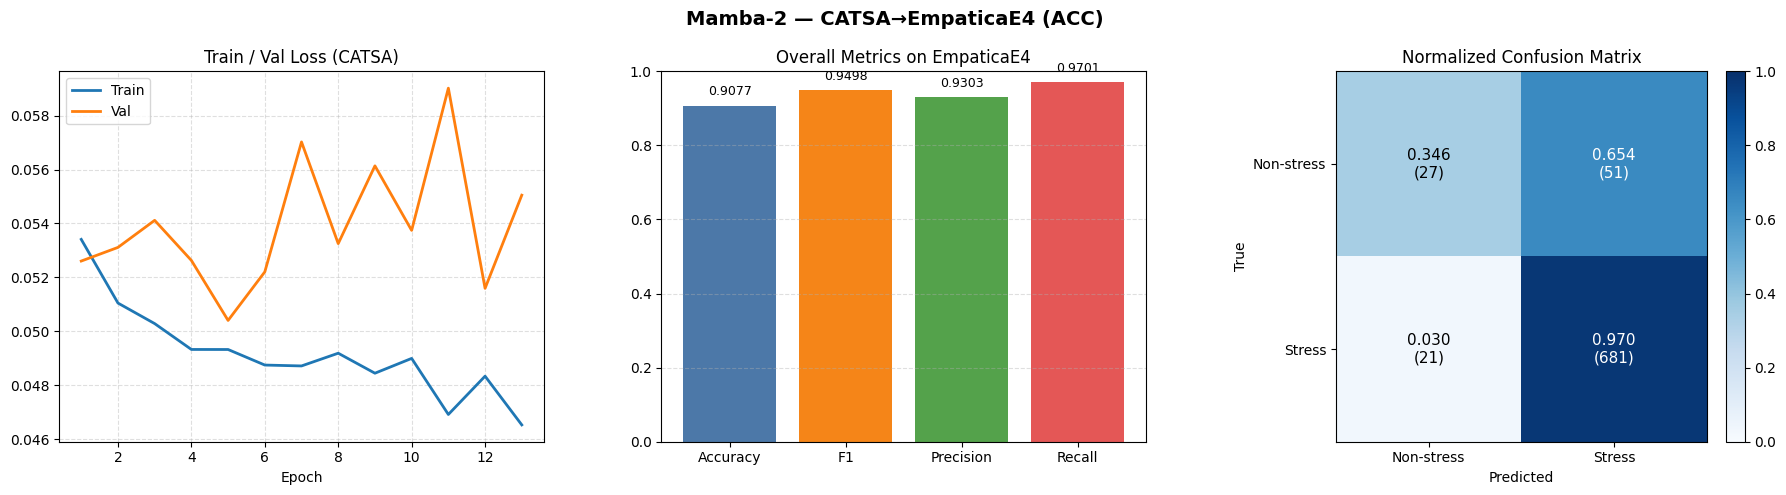

Saved results.png


In [5]:
# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_list = [h["epoch"] for h in history]
axes[0].plot(epochs_list, [h["train_loss"] for h in history], label="Train", linewidth=2)
axes[0].plot(epochs_list, [h["val_loss"]   for h in history], label="Val",   linewidth=2)
axes[0].set_title("Train / Val Loss (CATSA)"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(linestyle="--", alpha=0.4)

if all_true:
    bars = axes[1].bar(["Accuracy","F1","Precision","Recall"],
                       [ov_acc, ov_f1, ov_prec, ov_rec],
                       color=["#4C78A8","#F58518","#54A24B","#E45756"])
    axes[1].set_ylim(0, 1.0); axes[1].set_title("Overall Metrics on EmpaticaE4")
    axes[1].grid(axis="y", linestyle="--", alpha=0.4)
    for b, v in zip(bars, [ov_acc, ov_f1, ov_prec, ov_rec]):
        axes[1].text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.4f}",
                     ha="center", va="bottom", fontsize=9)

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    im = axes[2].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    axes[2].set_title("Normalized Confusion Matrix")
    axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
    axes[2].set_xticklabels(["Non-stress","Stress"])
    axes[2].set_yticklabels(["Non-stress","Stress"])
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
    thr = cm_norm.max() / 2
    for i in range(2):
        for j in range(2):
            axes[2].text(j, i, f"{cm_norm[i,j]:.3f}\n({cm[i,j]})",
                         ha="center", va="center",
                         color="white" if cm_norm[i,j] > thr else "black", fontsize=11)
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle("Mamba-2 — CATSA→EmpaticaE4 (ACC)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results.png")